In [29]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import tensorflow as tf
import time
class SiddonIncrementalRaytracer:
    """
    Incremental Siddon ray tracer with 2x2 entrance-plane supersampling.
    """
    def __init__(self, density: np.ndarray, source: np.ndarray, voxel_size: float):
        """
        density: 3D array (H, W, D)
        source:  [sx, sy, sz] coordinates
        voxel_size: scalar (vs)
        """
        self.density = density.astype(np.float64)
        self.source = source.astype(np.float64)
        self.vs = float(voxel_size)
        self.H, self.W, self.D = density.shape

    @staticmethod
    @njit(parallel=True, fastmath=True)
    def _supersample2x2_kernel(density, source, vs, acc, cnt):
        H, W, D = density.shape
        sx, sy, sz = source
        for ix0 in prange(W):
            for iz0 in range(D):
                for j in range(4):
                    dx = 0.25 + 0.5*(j//2)
                    dz = 0.25 + 0.5*(j%2)
                    x0 = (ix0 + dx) * vs
                    y0 = 0.0
                    z0 = (iz0 + dz) * vs
                    ux = x0 - sx; uy = y0 - sy; uz = z0 - sz
                    L = (ux*ux + uy*uy + uz*uz)**0.5
                    ux /= L; uy /= L; uz /= L
                    delta_s = vs / uy
                    rd_val = 0.0
                    for k in range(H):
                        t = (k * vs - sy) / uy
                        x_e = sx + ux * t
                        z_e = sz + uz * t
                        ix = int(x_e // vs)
                        iz = int(z_e // vs)
                        if ix < 0 or ix >= W or iz < 0 or iz >= D:
                            break
                        acc[k, ix, iz] += rd_val
                        cnt[k, ix, iz] += 1
                        rd_val += density[k, ix, iz] * delta_s

    def trace_supersampled2x2(self):
        """
        Perform 2x2 supersampled incremental Siddon on the full volume.
        Returns the averaged radiological-depth volume and the runtime in ms.
        """
        acc = np.zeros((self.H, self.W, self.D), dtype=np.float64)
        cnt = np.zeros((self.H, self.W, self.D), dtype=np.int32)
        # Warm up (compile kernel)
        self._supersample2x2_kernel(self.density, self.source, self.vs, acc, cnt)
        # Time the kernel
        t0 = time.time()
        self._supersample2x2_kernel(self.density, self.source, self.vs, acc, cnt)
        t_ms = (time.time() - t0) * 1000.0
        print(t_ms)
        # Compute average where count > 0
        rd = np.zeros_like(acc)
        nz = cnt > 0
        rd[nz] = acc[nz] / cnt[nz]
        return rd, t_ms

In [30]:
def siddon_trace_numpy(density_np, source_np, voxel_size):
    # Ensure NumPy arrays (not EagerTensors)
    density_np = np.array(density_np)
    source_np = np.array(source_np)
    
    tracer = SiddonIncrementalRaytracer(density_np, source_np, voxel_size)
    rd, _ = tracer.trace_supersampled2x2()
    return rd.astype(np.float32)

def siddon_tracer_tf(density, source, voxel_size):
    def numpy_fn(density_tf, source_tf):
        return siddon_trace_numpy(density_tf, source_tf, voxel_size)

    rd = tf.py_function(
        func=numpy_fn,
        inp=[density, source],
        Tout=tf.float32
    )
    rd.set_shape(density.shape)  # Important: set shape manually
    return rd


26.671886444091797
2×2 supersampled incremental trace time: 1037.5 ms


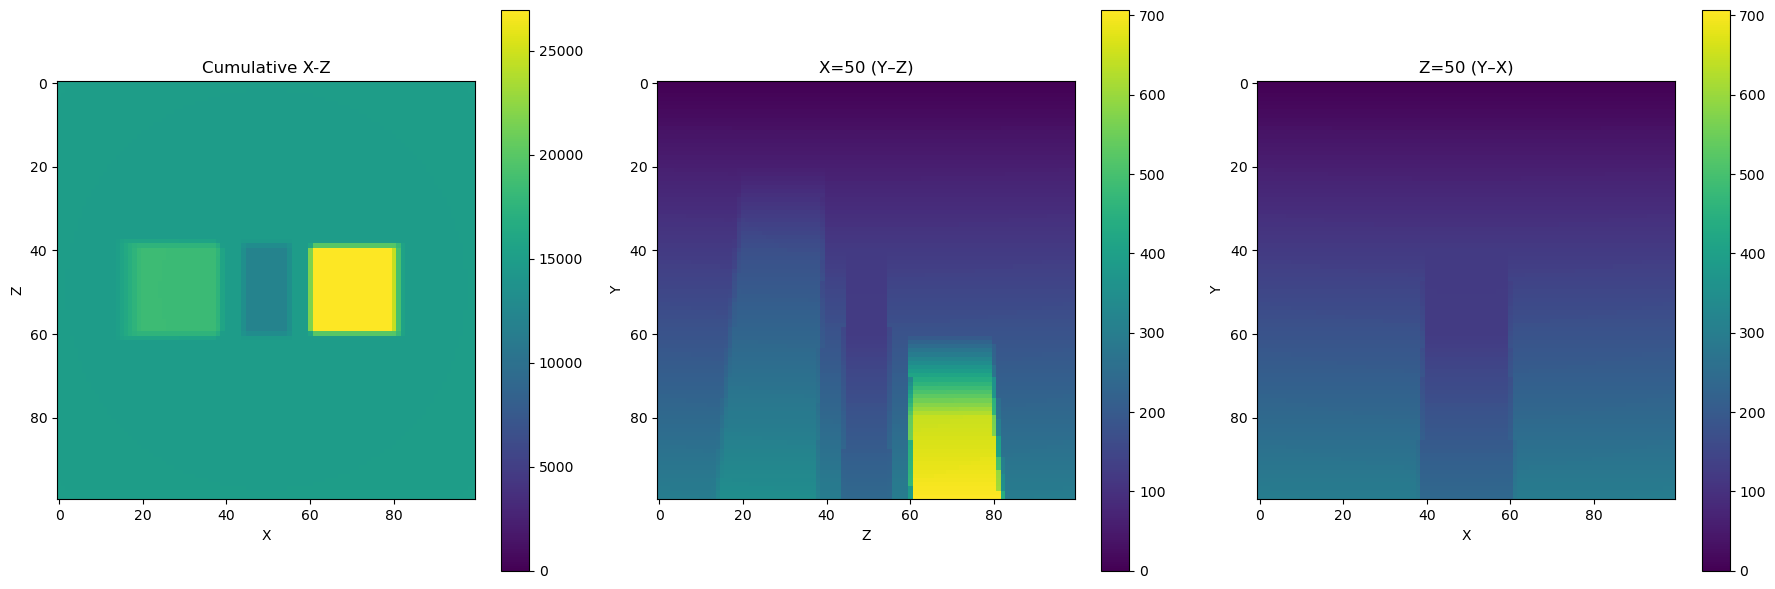

In [31]:

# Volume dimensions
H, W, D = 100, 100, 100
vs = 3.0
S = 1000.0
# Build phantom (same inserts, proportionally placed)
density = np.ones((H, W, D), dtype=np.float64)
density[40:60, 40:60, 45:55] = 0.05
density[20:40, 40:60, 20:40] = 1.85
density[60:80, 40:60, 60:80] = 7.8
# Source above y=0 at center
source = np.array([W * vs / 2.0, -S, D * vs / 2.0], dtype=np.float64)
# Instantiate tracer
start_time = time.time()
rd_sup = siddon_tracer_tf(tf.convert_to_tensor(density), tf.convert_to_tensor(source), vs).numpy()

print(f"2×2 supersampled incremental trace time: {1000*(time.time() - start_time):.1f} ms")
# Plot three orthogonal slices
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
vmin, vmax = rd_sup.min(), rd_sup.max()
im0 = ax[0].imshow(np.sum(rd_sup, axis=0), origin='upper', cmap='viridis', vmin=vmin, vmax=np.sum(rd_sup, axis=0).max())
ax[0].set_title('Cumulative X-Z'); ax[0].set_xlabel('X'); ax[0].set_ylabel('Z')
fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(rd_sup[:, W//2, :], origin='upper', cmap='viridis', vmin=vmin, vmax=vmax)
ax[1].set_title(f'X={W//2} (Y–Z)'); ax[1].set_xlabel('Z'); ax[1].set_ylabel('Y')
fig.colorbar(im1, ax=ax[1])
im2 = ax[2].imshow(rd_sup[:, :, D//2], origin='upper', cmap='viridis', vmin=vmin, vmax=vmax)
ax[2].set_title(f'Z={D//2} (Y–X)'); ax[2].set_xlabel('X'); ax[2].set_ylabel('Y')
fig.colorbar(im2, ax=ax[2])
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

def trilinear_interp(volume, coords):
    shape = tf.shape(volume)
    coords = tf.clip_by_value(coords, 0.0, tf.cast(shape - 1, tf.float32))

    c0 = tf.floor(coords)
    c1 = c0 + 1
    c0 = tf.cast(c0, tf.int32)
    c1 = tf.cast(c1, tf.int32)
    xd = coords[..., 0] - tf.cast(c0[..., 0], tf.float32)
    yd = coords[..., 1] - tf.cast(c0[..., 1], tf.float32)
    zd = coords[..., 2] - tf.cast(c0[..., 2], tf.float32)

    def get_vals(x, y, z):
        return tf.gather_nd(volume, tf.stack([y, x, z], axis=-1))

    c000 = get_vals(c0[..., 0], c0[..., 1], c0[..., 2])
    c001 = get_vals(c0[..., 0], c0[..., 1], c1[..., 2])
    c010 = get_vals(c0[..., 0], c1[..., 1], c0[..., 2])
    c011 = get_vals(c0[..., 0], c1[..., 1], c1[..., 2])
    c100 = get_vals(c1[..., 0], c0[..., 1], c0[..., 2])
    c101 = get_vals(c1[..., 0], c0[..., 1], c1[..., 2])
    c110 = get_vals(c1[..., 0], c1[..., 1], c0[..., 2])
    c111 = get_vals(c1[..., 0], c1[..., 1], c1[..., 2])

    c00 = c000 * (1 - zd) + c001 * zd
    c01 = c010 * (1 - zd) + c011 * zd
    c10 = c100 * (1 - zd) + c101 * zd
    c11 = c110 * (1 - zd) + c111 * zd
    c0 = c00 * (1 - yd) + c01 * yd
    c1 = c10 * (1 - yd) + c11 * yd
    return c0 * (1 - xd) + c1 * xd

def incremental_raytrace_tf(density, source, voxel_size, num_steps=200, ss_factor=2):
    H, W, D = tf.shape(density)
    vs = tf.cast(voxel_size, tf.float32)

    x = tf.range(W, dtype=tf.float32) + 0.5
    z = tf.range(D, dtype=tf.float32) + 0.5
    x, z = tf.meshgrid(x, z, indexing='ij')

    # 2x2 supersampling offsets
    offsets = tf.constant([[0.25, 0.25], [0.25, 0.75], [0.75, 0.25], [0.75, 0.75]], dtype=tf.float32)
    results = []

    for off in offsets:
        x_ss = (x + off[0]) * vs
        z_ss = (z + off[1]) * vs
        y_ss = tf.zeros_like(x_ss)

        dir = tf.stack([x_ss - source[0], y_ss - source[1], z_ss - source[2]], axis=-1)
        norm = tf.norm(dir, axis=-1, keepdims=True)
        dir /= norm

        t_vals = tf.linspace(0.0, tf.reduce_max(norm), num_steps)
        t_vals = tf.reshape(t_vals, [1, 1, -1, 1])  # shape [1, 1, steps, 1]

        rays = tf.expand_dims(tf.stack([x_ss, y_ss, z_ss], axis=-1), axis=2) + t_vals * tf.expand_dims(dir, axis=2)
        voxel_coords = rays / vs  # normalize to voxel indices

        sampled = trilinear_interp(density, voxel_coords)
        rd = tf.reduce_sum(sampled, axis=2) * (tf.reduce_max(t_vals) / num_steps)
        results.append(rd)

    return tf.reduce_mean(tf.stack(results, axis=0), axis=0)


In [ ]:
density_np = np.random.rand(100, 100, 100).astype(np.float32)
density_tf = tf.convert_to_tensor(density_np)
source_tf = tf.constant([150.0, -1000.0, 150.0], dtype=tf.float32)
rd_volume = incremental_raytrace_tf(density_tf, source_tf, voxel_size=3.0)


In [ ]:
rd_volume.shape

In [ ]:
import tensorflow as tf

def compute_ray_indices_tf(volume_shape, voxel_size, source, supersample=2, step_scale=1.0):
    H, W, D = volume_shape
    vs = tf.constant(voxel_size, dtype=tf.float32)

    offsets = tf.constant([[0.25, 0.25], [0.25, 0.75], [0.75, 0.25], [0.75, 0.75]], dtype=tf.float32)
    ix, iz = tf.meshgrid(tf.range(W, dtype=tf.float32), tf.range(D, dtype=tf.float32), indexing='ij')
    ix = tf.reshape(ix, [-1])
    iz = tf.reshape(iz, [-1])
    ix = tf.repeat(ix, supersample**2)
    iz = tf.repeat(iz, supersample**2)
    offset_id = tf.tile(tf.range(supersample**2), [W * D])
    sub_offsets = tf.gather(offsets, offset_id)

    x0 = (ix + sub_offsets[:, 0]) * vs
    z0 = (iz + sub_offsets[:, 1]) * vs
    y0 = tf.zeros_like(x0)
    target_pts = tf.stack([x0, y0, z0], axis=-1)

    dirs = target_pts - source[None, :]
    dir_norm = tf.norm(dirs, axis=-1, keepdims=True)
    dirs = dirs / dir_norm

    vol_diagonal = tf.norm(tf.constant(np.array([H * vs, W * vs, D * vs]), dtype=tf.float32))
    max_steps = tf.cast(tf.math.ceil(vol_diagonal / (vs * step_scale)), tf.int32)

    t_vals = tf.linspace(0.0, vol_diagonal, max_steps)
    t_vals = tf.reshape(t_vals, [1, -1, 1])
    rays = source[None, None, :] + t_vals * dirs[:, None, :]
    voxel_indices = tf.cast(tf.math.floor(rays / vs), tf.int32)

    voxel_indices_clipped = tf.clip_by_value(
        voxel_indices,
        clip_value_min=tf.constant([0, 0, 0], dtype=tf.int32),
        clip_value_max=tf.constant([H - 1, W - 1, D - 1], dtype=tf.int32)
    )
    return voxel_indices_clipped  # Shape: [R, T, 3]


In [12]:
def apply_raytrace_tf(density, ray_indices, voxel_size):
    """
    density: Tensor [B, H, W, D]
    ray_indices: Tensor [R, T, 3]
    """
    B = tf.shape(density)[0]
    R = tf.shape(ray_indices)[0]
    T = tf.shape(ray_indices)[1]

    ray_indices_batched = tf.tile(ray_indices[None, :, :, :], [B, 1, 1, 1])
    gathered = tf.gather_nd(density, ray_indices_batched, batch_dims=1)  # [B, R, T]
    step_len = tf.cast(voxel_size, tf.float32)
    rd = tf.reduce_sum(gathered, axis=-1) * step_len
    return rd  # Shape: [B, R]


In [13]:
volume_np = np.random.rand(1, 100, 100, 100).astype(np.float32)
density = tf.convert_to_tensor(volume_np)
source = tf.constant([150.0, -1000.0, 150.0], dtype=tf.float32)

ray_indices = compute_ray_indices_tf(volume_shape=(100, 100, 100), voxel_size=3.0, source=source)
rd = apply_raytrace_tf(density, ray_indices, voxel_size=3.0)
print("Raytraced depth shape:", rd.shape)


Raytraced depth shape: (1, 40000)


In [14]:
import tensorflow as tf

def compute_radiological_depth_volume(attenuation, source, voxel_size, num_steps=200):
    H, W, D = attenuation.shape
    vs = tf.constant(voxel_size, dtype=tf.float32)

    # Voxel centers in world coordinates
    x = tf.range(W, dtype=tf.float32) * vs + vs / 2
    y = tf.range(H, dtype=tf.float32) * vs + vs / 2
    z = tf.range(D, dtype=tf.float32) * vs + vs / 2
    grid_y, grid_x, grid_z = tf.meshgrid(y, x, z, indexing='ij')
    voxel_centers = tf.stack([grid_x, grid_y, grid_z], axis=-1)  # [H, W, D, 3]

    # Direction from source to each voxel
    dirs = voxel_centers - source
    norm = tf.norm(dirs, axis=-1, keepdims=True)
    dirs_unit = dirs / norm

    # March from source to each voxel center
    t_vals = tf.linspace(0.0, 1.0, num_steps)[None, None, None, :, None]  # [1, 1, 1, T, 1]
    rays = source + t_vals * dirs_unit[..., None, :] * norm[..., None, :]  # [H, W, D, T, 3]
    rays = tf.reshape(rays, [-1, num_steps, 3])

    # Convert to voxel space
    coords = rays / vs

    def trilinear_interp(volume, coords):
        shape = tf.cast(tf.shape(volume), tf.float32)
        coords = tf.clip_by_value(coords, 0.0, shape - 1.001)

        c0 = tf.floor(coords)
        c1 = c0 + 1
        c0 = tf.cast(c0, tf.int32)
        c1 = tf.cast(c1, tf.int32)
        xd = coords[..., 0] - tf.cast(c0[..., 0], tf.float32)
        yd = coords[..., 1] - tf.cast(c0[..., 1], tf.float32)
        zd = coords[..., 2] - tf.cast(c0[..., 2], tf.float32)

        def get(x, y, z):
            return tf.gather_nd(volume, tf.stack([y, x, z], axis=-1))

        c000 = get(c0[..., 0], c0[..., 1], c0[..., 2])
        c001 = get(c0[..., 0], c0[..., 1], c1[..., 2])
        c010 = get(c0[..., 0], c1[..., 1], c0[..., 2])
        c011 = get(c0[..., 0], c1[..., 1], c1[..., 2])
        c100 = get(c1[..., 0], c0[..., 1], c0[..., 2])
        c101 = get(c1[..., 0], c0[..., 1], c1[..., 2])
        c110 = get(c1[..., 0], c1[..., 1], c0[..., 2])
        c111 = get(c1[..., 0], c1[..., 1], c1[..., 2])

        c00 = c000 * (1 - zd) + c001 * zd
        c01 = c010 * (1 - zd) + c011 * zd
        c10 = c100 * (1 - zd) + c101 * zd
        c11 = c110 * (1 - zd) + c111 * zd
        c0 = c00 * (1 - yd) + c01 * yd
        c1 = c10 * (1 - yd) + c11 * yd
        return c0 * (1 - xd) + c1 * xd

    samples = trilinear_interp(attenuation, coords)
    path_lengths = tf.reshape(norm, [-1]) / num_steps
    rd = tf.reduce_sum(samples, axis=1) * path_lengths
    return tf.reshape(rd, [H, W, D])


In [15]:
# Assuming attenuation is a [100, 100, 100] tensor
attenuation = tf.convert_to_tensor(np.random.rand(100, 100, 100).astype(np.float32))
source = tf.constant([150.0, -1000.0, 150.0], dtype=tf.float32)
voxel_size = 3.0

rd_volume = compute_radiological_depth_volume(attenuation, source, voxel_size)
print(rd_volume.shape)  # Should be (100, 100, 100)


2025-04-23 20:33:01.035484: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.23GiB (rounded to 2400000000)requested by op AddV2
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-04-23 20:33:01.035521: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1058] BFCAllocator dump for GPU_0_bfc
2025-04-23 20:33:01.035528: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1065] Bin (256): 	Total Chunks: 32, Chunks in use: 32. 8.0KiB allocated for chunks. 8.0KiB in use in bin. 225B client-requested in use in bin.
2025-04-23 20:33:01.035532: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1065] Bin (512): 	Total Chunks: 4, Chunks in use: 3. 2.0KiB allocated for chunks. 1.5KiB in use in bin. 1.2KiB client-requested in use in bin.
2025-04-23 20:33:

ResourceExhaustedError: {{function_node __wrapped__AddV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} failed to allocate memory [Op:AddV2] name: 